In [1]:
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

# 1. Create a dataset with 3 features
X, y = make_regression(n_samples=1000, n_features=3, noise=0.1, random_state=42)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 4. Predictions
y_pred = mlr_model.predict(X_test)

# 5. Metrics Calculation
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

# Adjusted R-Squared calculation
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f} | Adjusted R2: {adj_r2:.4f}")

MAE: 0.0820 | MSE: 0.0103 | RMSE: 0.1014
R2 Score: 1.0000 | Adjusted R2: 1.0000


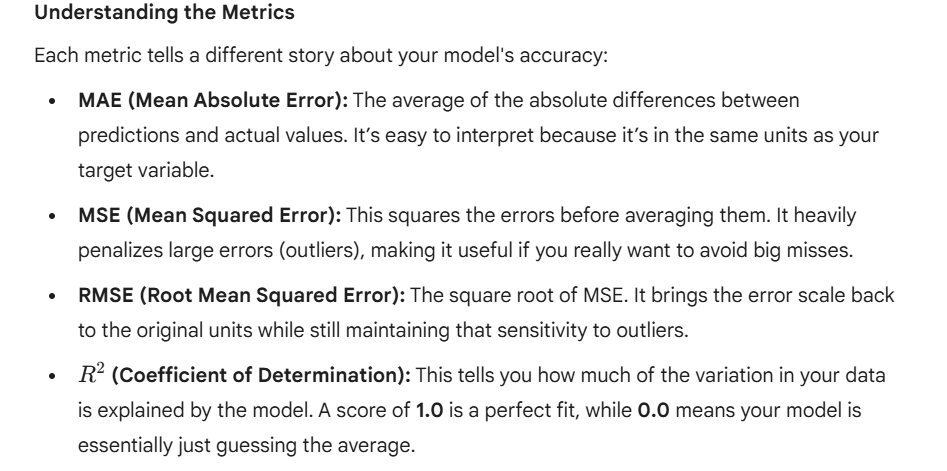

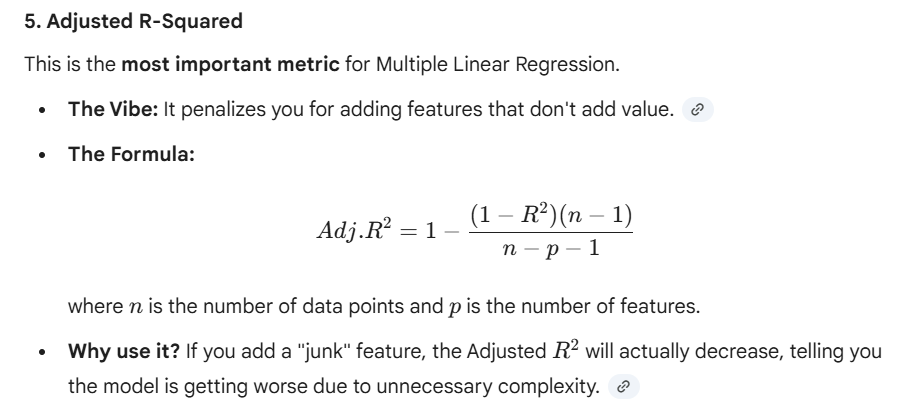

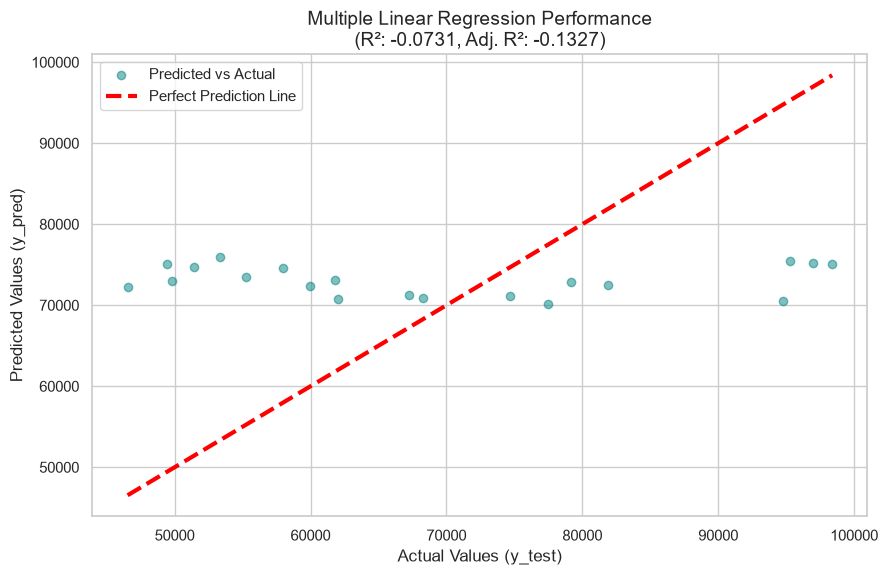

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style
sns.set_theme(style="whitegrid")

# 2. Create the Plot
plt.figure(figsize=(10, 6))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Predicted vs Actual')

# Plot the "Perfect Fit" line (where Actual == Predicted)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=3, label='Perfect Prediction Line')

# 3. Add Labels and Title
plt.title(f'Multiple Linear Regression Performance\n(R²: {r2:.4f}, Adj. R²: {adj_r2:.4f})', fontsize=14)
plt.xlabel('Actual Values (y_test)', fontsize=12)
plt.ylabel('Predicted Values (y_pred)', fontsize=12)
plt.legend()

# Show the plot
plt.show()